# Diabetes Health Indicators
# Lab 2: Logistic Regression and Support Vector Machines

## BRFSS 2015 Diabetes Health Indicators Dataset

**Project Team:** Harvey, Sydney, Wolfgang, Nashita
**Course:** Intro to AI
**Date:** September 2026

# 1. Introduction

## 1.1 The Classification Task

In Lab 1 we explored the BRFSS 2015 diabetes health indicators data (253,680
respondents, 21 features). In this lab we do the Modeling and Evaluation steps of
CRISP-DM. We fit a logistic regression and a support vector machine to the same
task, tune both, compare them, and look at what each model tells us about the
data.

We use the same target as Lab 1, `Diabetes_binary`. It is 1 if the respondent
says a doctor told them they have prediabetes or diabetes, and 0 otherwise.
15.76% of respondents are in the positive class.

As in Lab 1, the target is a *diagnosis*, not the disease itself. Someone who has
diabetes but was never tested is counted as a 0. So the models learn who has been
diagnosed, and this limits how accurate any of them can be.

## 1.2 How the Models Are Judged

The model is meant to flag people who should be referred for a diabetes screening
test. Missing a case is costly, because diabetes gets worse without treatment. An
unnecessary referral also costs time and money, but less.

The data is imbalanced. Predicting "no diabetes" for everyone already gets 84%
accuracy, so we report accuracy but don't use it to pick models.

| Metric | What it measures | How we use it |
|---|---|---|
| ROC-AUC | How well the model ranks diabetics above non-diabetics, over all thresholds (0.5 = guessing, 1 = perfect) | Used for all hyperparameter searches. |
| Recall | Share of diagnosed diabetics the model flags | Missing a case is the worst error here. |
| Precision | Share of flagged people who are actually diagnosed | Shows how many referrals are false alarms. |
| F2 | Combines precision and recall, but counts recall 4 times as much | Used to pick each model's threshold and to rank the final models. |
| Fit time | Seconds to train the model once | Used for the efficiency question in Section 5. |

F2 is calculated as

$$
F_2 = \frac{5 \cdot \text{Precision} \cdot \text{Recall}}{4 \cdot \text{Precision} + \text{Recall}}
$$

ROC-AUC only depends on how the model ranks people. That means we can use it for
both the logistic regression (which outputs a probability) and the SVM (which
outputs a decision value, not a probability).

## 1.3 Assumptions and Decisions Carried Over from Lab 1

1. Binary target: prediabetes (1.8% of rows) is combined with diabetes, as in Lab 1.
2. We drop the healthcare-access variables `CholCheck`, `AnyHealthcare` and
   `NoDocbcCost`. Lab 1 (Section 15.2) showed they measure who gets *diagnosed*
   more than who is sick. That leaves 18 features.
3. We keep duplicate rows. Lab 1 showed that removing them would artificially
   raise the prevalence. Identical rows are real people who happened to give the
   same answers to 18 fairly coarse questions.
4. We use raw BMI. A few extreme values don't have much effect on a linear model
   with standardized features, and the raw column is easier to interpret (odds
   per BMI point).
5. Ordinal features are treated as numbers. `Age` (13 bands), `GenHlth` (1-5),
   `Education` (1-6) and `Income` (1-8) are each one numeric column. This assumes
   each step up the scale has the same effect on the log-odds. That is a
   simplification, since Lab 1 found the age curve bends down in the oldest bands.
6. All features are standardized inside a pipeline, so the scaler only learns
   means and standard deviations from the training rows. SVMs need this, and it
   also lets us compare the logistic weights across features.
7. Class weights are tuned for logistic regression (Section 3.2). The SVMs use
   `class_weight="balanced"`, so a missed diabetic counts about 5.3 times as much
   as a false alarm during training.
8. We use an 80/20 stratified split with seed 42, as the assignment asks. All
   tuning, including the choice of threshold, is done with cross-validation inside
   the 80%. The 20% test set is only used for the final numbers.

# 2. Setup and Data Preparation

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")
os.environ["PYTHONWARNINGS"] = "ignore"   # silence the parallel worker processes too

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     StratifiedKFold, cross_val_predict)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.metrics import (accuracy_score, recall_score, precision_score, fbeta_score,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             confusion_matrix)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", "{:.3f}".format)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.titleweight"] = "bold"

# Same palette as Lab 1, so a colour means the same thing in both reports
PALETTE = {
    "ink":    "#22303c",
    "grid":   "#dfe4e8",
    "neg":    "#8fa3b0",   # reference / unexposed
    "pos":    "#b5442e",   # diabetes / elevated
    "prot":   "#2f6f6a",   # protective direction
    "accent": "#c98a1b",
}
SEQ = sns.blend_palette(["#f5f2ea", "#d8b26a", PALETTE["pos"], "#5c1d13"], as_cmap=True)

SEED = 42
CV5  = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
raw = pd.read_csv("../data/diabetes_012_health_indicators_BRFSS2015.csv")

# Decision #1 (Lab 1): collapse prediabetes and diabetes into one positive class
raw["Diabetes_binary"] = (raw["Diabetes_012"] >= 1).astype(int)
TARGET = "Diabetes_binary"

# Decision #7 (Lab 1): withhold the healthcare-access variables, which measure
# who gets diagnosed rather than who is sick
ACCESS   = ["CholCheck", "AnyHealthcare", "NoDocbcCost"]
FEATURES = [c for c in raw.columns if c not in ["Diabetes_012", TARGET] + ACCESS]

X = raw[FEATURES].astype(float)
y = raw[TARGET]

print(f"rows       : {len(raw):,}")
print(f"features   : {len(FEATURES)}  (dropped {', '.join(ACCESS)})")
print(f"prevalence : {100*y.mean():.2f}%")

rows       : 253,680
features   : 18  (dropped CholCheck, AnyHealthcare, NoDocbcCost)
prevalence : 15.76%


The split is stratified, so both sides have the same 15.8% prevalence. We only
split once. Every model below is trained on the same 202,944 training rows (or a
sample of them) and tested on the same 50,736 test rows.

In [3]:
# 80/20 split as the assignment requires, stratified so both sides carry the same
# class balance. The test set is not touched again until models are compared.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)

print(f"Training rows : {len(X_train):,}   positive rate {y_train.mean():.3f}")
print(f"Test rows     : {len(X_test):,}    positive rate {y_test.mean():.3f}")

Training rows : 202,944   positive rate 0.158
Test rows     : 50,736    positive rate 0.158


In [4]:
results, preds = [], {}

def evaluate(name, score, pred, fit_seconds=np.nan):
    """Test-set metrics. `score` is a probability or an SVM decision value:
    ROC-AUC only needs a ranking, so either works."""
    row = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "F2": fbeta_score(y_test, pred, beta=2),
        "ROC-AUC": roc_auc_score(y_test, score),
        "Fit time (s)": fit_seconds,
    }
    results.append(row)
    preds[name] = pred
    return row

def timed_fit(model, X_, y_):
    t0 = time.perf_counter()
    model.fit(X_, y_)
    return model, time.perf_counter() - t0

def f2_curve(y_true, score):
    """Precision, recall and F2 at every possible threshold on `score`."""
    p, r, t = precision_recall_curve(y_true, score)
    p, r = p[:-1], r[:-1]
    f2 = 5 * p * r / np.clip(4 * p + r, 1e-12, None)
    return t, p, r, f2

def f2_threshold(y_true, score):
    """Threshold on `score` that gives the highest F2."""
    t, p, r, f2 = f2_curve(y_true, score)
    return t[np.argmax(f2)]

def plot_threshold(ax, y_true, score, title, xlabel):
    """Precision, recall and F2 against the threshold, with the best F2 marked
    (Wolfgang's threshold plot)."""
    t, p, r, f2 = f2_curve(y_true, score)
    i = np.argmax(f2)
    ax.plot(t, p, color=PALETTE["prot"], lw=1.8, label="precision")
    ax.plot(t, r, color=PALETTE["pos"], lw=1.8, label="recall")
    ax.plot(t, f2, color=PALETTE["ink"], lw=2.2, label="F2")
    ax.axvline(t[i], color=PALETTE["accent"], ls="--", lw=1.2)
    ax.plot(t[i], f2[i], "o", color=PALETTE["accent"], ms=8)
    ax.annotate(f"threshold {t[i]:.3f}\nF2 {f2[i]:.3f}", (t[i], f2[i]), xytext=(8, 12),
                textcoords="offset points", color=PALETTE["accent"], fontsize=9)
    ax.set_xlim(*np.percentile(score, [0.5, 99.5])); ax.set_ylim(0, 1.02)
    ax.set_xlabel(xlabel); ax.set_ylabel("score")
    ax.set_title(title); ax.legend(frameon=False, loc="upper right")

def show_results(names=None):
    df = pd.DataFrame(results).drop_duplicates("Model", keep="last").set_index("Model")
    return (df if names is None else df.loc[names]).round(3)

# 3. Logistic Regression

## 3.1 Baseline

We start with three baselines: a model that predicts nobody has diabetes,
logistic regression with scikit-learn's default settings, and the same model
with balanced class weights (our preliminary model from Lab 1).

In [5]:
dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
evaluate("Predict nobody has diabetes",
         dummy.predict_proba(X_test)[:, 1], dummy.predict(X_test))

def logit_pipe(**kw):
    return Pipeline([("scale", StandardScaler()),
                     ("clf", LogisticRegression(max_iter=2000, random_state=SEED, **kw))])

lr_default, t = timed_fit(logit_pipe(), X_train, y_train)
p = lr_default.predict_proba(X_test)[:, 1]
evaluate("Logistic, default", p, (p >= 0.5).astype(int), t)

lr_weighted, t = timed_fit(logit_pipe(class_weight="balanced"), X_train, y_train)
p = lr_weighted.predict_proba(X_test)[:, 1]
evaluate("Logistic, class-weighted", p, (p >= 0.5).astype(int), t)

show_results()

,Accuracy,Recall,Precision,F2,ROC-AUC,Fit time (s)
Model,,,,,,
Predict nobody has diabetes,0.842,0.000,0.000,0.000,0.500,NaN
"Logistic, default",0.848,0.189,0.552,0.217,0.816,0.235
"Logistic, class-weighted",0.730,0.759,0.341,0.609,0.816,0.269


### Interpretation

The default logistic regression is less than one point more accurate than the
do-nothing baseline (84.8% vs 84.2%), and it only finds 19% of the diabetics.
With a 0.50 cut-off and only 16% positives, it almost never predicts diabetes.

Class weighting raises recall from 19% to 76%, but accuracy drops by 12 points.
ROC-AUC stays at 0.816 for both. So weighting doesn't make the model better at
ranking people. It just changes which kind of mistake the model makes more
often. We come back to this difference between ranking and the chosen cut-off
throughout the report.

## 3.2 Tuning the Parameters

We tune three parameters with 5-fold cross-validation, scored on ROC-AUC:

* `C`, the regularization strength. A smaller `C` shrinks the weights more toward zero.
* The penalty. L2 shrinks all the weights a little, and L1 can set some weights
  to exactly zero.
* The class weight: how much more a missed diabetic counts than a false alarm.
  "balanced" weights each class by the inverse of its frequency (about 5.3 times
  for diabetics), and we also try 1.5 and 2 times that (Sydney's class-weight grid).

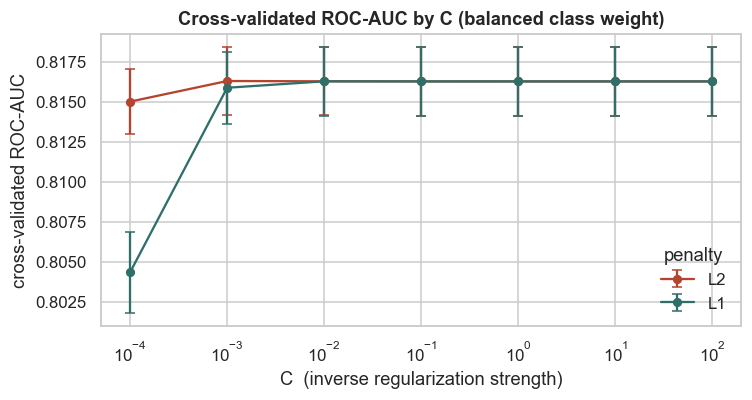

,best CV ROC-AUC
weight,
balanced,0.816
"{0: 1, 1: 10.69}",0.816
"{0: 1, 1: 8.02}",0.816


best parameters : {'clf__C': np.float64(0.001), 'clf__class_weight': {0: 1, 1: 10.69}, 'clf__l1_ratio': 0}
best CV ROC-AUC : 0.8163
spread across C >= 0.01 : [0.8163, 0.8163]
grid search time: 52s for 210 fits


In [6]:
# Sydney's class-weight grid: balanced, then 1.5x and 2x the balanced weight
neg_pos = float((y_train == 0).sum() / (y_train == 1).sum())
CLASS_WEIGHTS = ["balanced", {0: 1, 1: round(1.5 * neg_pos, 2)}, {0: 1, 1: round(2 * neg_pos, 2)}]

lr_grid = GridSearchCV(
    Pipeline([("scale", StandardScaler()),
              ("clf", LogisticRegression(solver="liblinear", max_iter=2000, random_state=SEED))]),
    # l1_ratio=1 is the L1 (lasso) penalty, l1_ratio=0 is L2 (ridge)
    param_grid={"clf__C": np.logspace(-4, 2, 7), "clf__l1_ratio": [0, 1],
                "clf__class_weight": CLASS_WEIGHTS},
    scoring="roc_auc", cv=CV5, n_jobs=-1)

t0 = time.perf_counter()
lr_grid.fit(X_train, y_train)
lr_search_time = time.perf_counter() - t0

cv_lr = pd.DataFrame(lr_grid.cv_results_)
cv_lr = cv_lr.assign(C=cv_lr.param_clf__C.astype(float),
                     penalty=np.where(cv_lr.param_clf__l1_ratio.astype(float) == 1, "l1", "l2"),
                     weight=cv_lr.param_clf__class_weight.astype(str))

fig, ax = plt.subplots(figsize=(7, 3.8))
d_bal = cv_lr[cv_lr.weight == "balanced"]
for pen, color in [("l2", PALETTE["pos"]), ("l1", PALETTE["prot"])]:
    d = d_bal[d_bal.penalty == pen].sort_values("C")
    ax.errorbar(d.C, d.mean_test_score, yerr=d.std_test_score, fmt="-o", ms=5,
                capsize=3, color=color, label=pen.upper())
ax.set_xscale("log")
ax.set_xlabel("C  (inverse regularization strength)")
ax.set_ylabel("cross-validated ROC-AUC")
ax.set_title("Cross-validated ROC-AUC by C (balanced class weight)")
ax.legend(title="penalty", frameon=False)
plt.tight_layout(); plt.show()

# Best ROC-AUC for each class weight
display(cv_lr.groupby("weight").mean_test_score.max().rename("best CV ROC-AUC").to_frame().round(4))

print(f"best parameters : {lr_grid.best_params_}")
print(f"best CV ROC-AUC : {lr_grid.best_score_:.4f}")
print(f"spread across C >= 0.01 : "
      f"{cv_lr[cv_lr.C >= 0.01].mean_test_score.agg(['min', 'max']).round(4).tolist()}")
print(f"grid search time: {lr_search_time:.0f}s for {len(cv_lr) * 5} fits")

### Interpretation

Tuning barely matters here. With L2, the cross-validated ROC-AUC is 0.816 for
every `C` from 0.001 to 100. Only very strong regularization hurts: at
`C = 0.0001`, L1 drops to 0.804 because it starts removing useful features. The
class weight doesn't change ROC-AUC at all (0.816 for all three). The search
picks `C = 0.001`, L2 and twice the balanced weight, but it only beats the other
settings in the fourth decimal, which is smaller than the variation between folds.

This makes sense with 203k rows and 18 features. That is about 11,000 rows per
parameter, so the model can't really overfit, and regularization has nothing to
fix. The model is limited by bias instead: the features are simple, mostly
yes/no survey answers, and the target is a diagnosis rather than a measurement.
Tuning can't change either of those.

The class weight result matches what Sydney found. In her search, scored on F2
with the threshold fixed at 0.50, class weight was the only parameter that
mattered, and doubling the balanced weight pushed recall to about 85%. A bigger
class weight and a lower threshold do the same job: both make the model flag
more people. Since the class weight doesn't change the ranking, we control that
tradeoff with the threshold in the next step.

## 3.3 Choosing the Decision Threshold

Since tuning doesn't improve the ranking much, the other thing we can change is
the decision threshold. We pick the threshold that gives the best F2 on
*out-of-fold* predictions from the training set: each training row gets a
prediction from a model that didn't see it during training. This way the test
set isn't used to choose the threshold. The plot shows how precision, recall and
F2 change as the threshold moves.

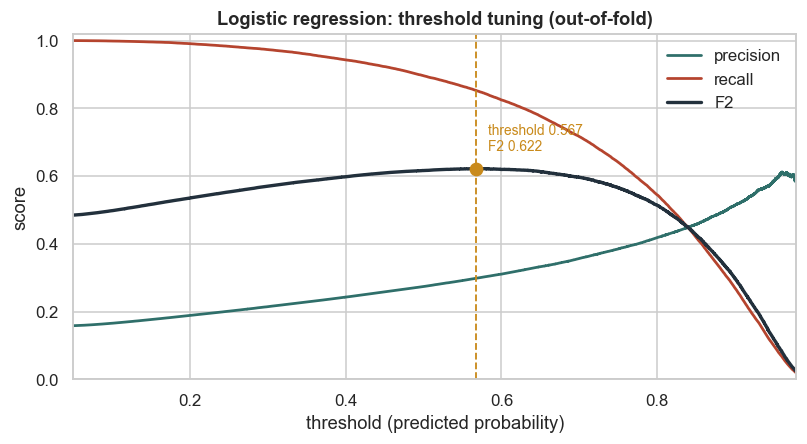

F2 threshold from out-of-fold training predictions: 0.567


,Accuracy,Recall,Precision,F2,ROC-AUC,Fit time (s)
Model,,,,,,
Predict nobody has diabetes,0.842,0.000,0.000,0.000,0.500,NaN
"Logistic, default",0.848,0.189,0.552,0.217,0.816,0.235
"Logistic, class-weighted",0.730,0.759,0.341,0.609,0.816,0.269
"Logistic, tuned (0.50)",0.609,0.893,0.273,0.615,0.816,0.565
"Logistic, tuned (F2 threshold)",0.660,0.846,0.297,0.618,0.816,0.565


In [7]:
lr_best = lr_grid.best_estimator_
_, lr_fit_time = timed_fit(lr_best, X_train, y_train)

# Out-of-fold probabilities on the training set pick the threshold, so the test
# set plays no part in the choice
oof_lr = cross_val_predict(lr_best, X_train, y_train, cv=CV5,
                           method="predict_proba", n_jobs=-1)[:, 1]
lr_thr = f2_threshold(y_train, oof_lr)

fig, ax = plt.subplots(figsize=(7.5, 4.2))
plot_threshold(ax, y_train, oof_lr, "Logistic regression: threshold tuning (out-of-fold)",
               "threshold (predicted probability)")
plt.tight_layout(); plt.show()

p_lr = lr_best.predict_proba(X_test)[:, 1]
evaluate("Logistic, tuned (0.50)", p_lr, (p_lr >= 0.5).astype(int), lr_fit_time)
evaluate("Logistic, tuned (F2 threshold)", p_lr, (p_lr >= lr_thr).astype(int), lr_fit_time)

print(f"F2 threshold from out-of-fold training predictions: {lr_thr:.3f}")
show_results()

### Interpretation

At the F2 threshold (0.567), the tuned model finds 84.6% of diagnosed diabetics
at 29.7% precision, and F2 is 0.618. At the default 0.50 it flags more people:
recall is 89.3%, precision drops to 27.3%, and F2 is 0.615. ROC-AUC is 0.816
either way because the ranking doesn't change. The threshold is above 0.50
because the doubled class weight pushes all the predicted probabilities up, so
0.567 here is not a real 57% chance of diabetes.

The F2 curve in the plot is quite flat between about 0.45 and 0.65, so the exact
threshold doesn't matter much. A program with a tighter budget for follow-up
tests could move the threshold up, trading some recall for fewer false alarms.

# 4. Support Vector Machines

## 4.1 Choosing a Kernel

An SVM finds the boundary between the classes with the widest possible margin.
The kernel controls the shape of that boundary. A linear kernel gives a flat
boundary (a hyperplane), like logistic regression. An RBF (radial basis
function) kernel lets the boundary curve around groups of points.

The assignment says that if the dataset is too large for a kernel SVM, a linear
kernel is fine. Before deciding, we checked this by timing scikit-learn's `SVC`
(the general kernel SVM solver, libsvm) on bigger and bigger samples of the
training set.

In [8]:
# Fit kernel SVMs on growing stratified subsamples and time them
sizes, timing = [2_500, 5_000, 10_000, 20_000], []
for n in sizes:
    Xs, _, ys, _ = train_test_split(X_train, y_train, train_size=n,
                                    random_state=SEED, stratify=y_train)
    for kernel in ["linear", "rbf"]:
        m = Pipeline([("scale", StandardScaler()),
                      ("clf", SVC(kernel=kernel, C=1.0, class_weight="balanced"))])
        _, t = timed_fit(m, Xs, ys)
        timing.append({"n": n, "kernel": kernel, "seconds": t,
                       "support vectors": m[-1].n_support_.sum()})
timing = pd.DataFrame(timing)
display(timing.pivot(index="n", columns="kernel", values=["seconds", "support vectors"]).round(1))

# Rough estimate for the full training set: if time grows with the square of the
# rows, going from 20,000 rows to all of them multiplies the time by (n_full / 20,000)^2
n_full = len(X_train)
t20k = timing[timing.n == 20_000].set_index("kernel")["seconds"]
extrap = t20k * (n_full / 20_000) ** 2
for kernel, secs in extrap.items():
    print(f"{kernel:6s}: {t20k[kernel]:.0f}s at 20,000 rows  ->  roughly {secs/3600:.1f} hours "
          f"at {n_full:,} rows (one fit, one setting of C)")

seconds        support vectors          
kernel  linear    rbf          linear       rbf
n                                              
2500     0.300  0.200        1574.000  1568.000
5000     1.200  0.900        3021.000  2956.000
10000    5.500  4.600        6037.000  5820.000
20000   18.400 18.100       12020.000 11501.000

linear: 18s at 20,000 rows  ->  roughly 0.5 hours at 202,944 rows (one fit, one setting of C)
rbf   : 18s at 20,000 rows  ->  roughly 0.5 hours at 202,944 rows (one fit, one setting of C)


### Interpretation

`SVC` fit time grows roughly with the square of the number of rows, for both
kernels. Going from 10,000 to 20,000 rows makes it about three to four times
slower (about 5 seconds to about 18). For all 202,944 training rows, a single fit
with a single value of `C` would take about half an hour. A 5-fold grid search
over a dozen settings would take more than a day. Predicting is slow too, because
an RBF model compares each new row with every support vector, and more than half
of the training rows end up as support vectors (right-hand column).

The slow part is the libsvm solver, not the kernel. `LinearSVC` uses a solver
made for the linear case, which doesn't need to compare every row with every
other row. So our plan is:

1. Linear kernel on the full training set (Section 4.2). This is our main SVM,
   and the one we compare with logistic regression.
2. RBF kernel on a 10,000-row sample (Section 4.3), to see if a curved boundary
   finds anything a straight one misses. Based on Lab 1 we don't expect much,
   because age and BMI add up almost linearly on the log-odds scale (Lab 1,
   Section 7.6), which is what a linear model can already capture.

## 4.2 Linear SVM on the Full Training Set

We tune `LinearSVC` over `C` (a larger `C` means a narrower margin that allows
fewer points inside it). It uses balanced class weights and 5-fold
cross-validation on ROC-AUC, like the logistic regression. The threshold is then
picked the same way, by the best out-of-fold F2. The SVM outputs a decision value
(a signed distance from the boundary), so its threshold is on that scale instead
of a probability.

In [9]:
svm_grid = GridSearchCV(
    Pipeline([("scale", StandardScaler()),
              ("clf", LinearSVC(dual=False, class_weight="balanced", random_state=SEED))]),
    param_grid={"clf__C": np.logspace(-4, 1, 6)},
    scoring="roc_auc", cv=CV5, n_jobs=-1)
svm_grid.fit(X_train, y_train)

display(pd.DataFrame({
    "C (LinearSVC)": svm_grid.cv_results_["param_clf__C"].astype(float),
    "CV ROC-AUC": svm_grid.cv_results_["mean_test_score"]}).round(4).T)
print(f"LinearSVC best : {svm_grid.best_params_}  CV ROC-AUC {svm_grid.best_score_:.4f}")

,0,1,2,3,4,5
C (LinearSVC),0.000,0.001,0.010,0.100,1.000,10.000
CV ROC-AUC,0.816,0.816,0.816,0.816,0.816,0.816


LinearSVC best : {'clf__C': np.float64(0.01)}  CV ROC-AUC 0.8159


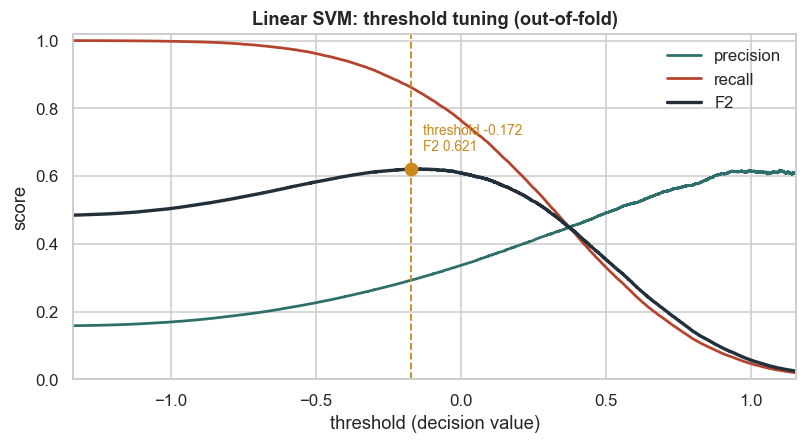

F2 threshold for the linear SVM (decision value): -0.172


,Accuracy,Recall,Precision,F2,ROC-AUC,Fit time (s)
Model,,,,,,
"Logistic, tuned (0.50)",0.609,0.893,0.273,0.615,0.816,0.565
"Logistic, tuned (F2 threshold)",0.660,0.846,0.297,0.618,0.816,0.565
Linear SVM (0 margin),0.727,0.765,0.338,0.611,0.816,0.453
Linear SVM (F2 threshold),0.649,0.857,0.291,0.617,0.816,0.453


In [10]:
svm_best = svm_grid.best_estimator_
_, svm_fit_time = timed_fit(svm_best, X_train, y_train)
oof_svm = cross_val_predict(svm_best, X_train, y_train, cv=CV5,
                            method="decision_function", n_jobs=-1)
svm_thr = f2_threshold(y_train, oof_svm)

fig, ax = plt.subplots(figsize=(7.5, 4.2))
plot_threshold(ax, y_train, oof_svm, "Linear SVM: threshold tuning (out-of-fold)",
               "threshold (decision value)")
plt.tight_layout(); plt.show()

d_svm = svm_best.decision_function(X_test)
evaluate("Linear SVM (0 margin)", d_svm, (d_svm >= 0).astype(int), svm_fit_time)
evaluate("Linear SVM (F2 threshold)", d_svm, (d_svm >= svm_thr).astype(int), svm_fit_time)

print(f"F2 threshold for the linear SVM (decision value): {svm_thr:.3f}")
show_results(["Logistic, tuned (0.50)", "Logistic, tuned (F2 threshold)",
              "Linear SVM (0 margin)", "Linear SVM (F2 threshold)"])

### Interpretation

The linear SVM behaves just like the logistic regression. Its cross-validated
ROC-AUC is 0.816 for every `C` from 0.0001 to 10, so tuning doesn't matter here
either, for the same reason as before. Wolfgang searched a wider grid for the
linear SVM (15 values of `C`, L1 and L2 penalties, with and without class
weights) and found the same flat curve.

On the test set the two models are basically the same. ROC-AUC is 0.816 for
both. At their F2 thresholds, the SVM finds 85.7% of diabetics at 29.1% precision
and the logistic regression finds 84.6% at 29.7%, so F2 is 0.617 vs 0.618.
Differences this small could easily come from a different random split.

## 4.3 RBF Kernel on a Subsample

The RBF kernel has two parameters: `C` like before, and `gamma`, which controls
how far each training point's influence reaches. A large `gamma` gives a wiggly
boundary that follows individual points, and a small `gamma` gives a smoother one.
We search both on a stratified 10,000-row sample with 3-fold cross-validation.
We also fit a linear-kernel `SVC` on the same sample so the two kernels are
compared on the same data.

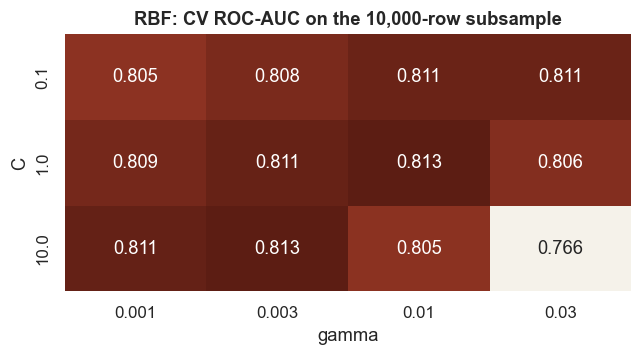

RBF best          : {'clf__C': 1, 'clf__gamma': 0.01}  CV ROC-AUC 0.8131   (grid search 26s)
linear SVC best   : {'clf__C': 0.1}  CV ROC-AUC 0.8085


In [11]:
N_SUB = 10_000
X_sub, _, y_sub, _ = train_test_split(X_train, y_train, train_size=N_SUB,
                                      random_state=SEED, stratify=y_train)
CV3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

def svc_pipe(**kw):
    return Pipeline([("scale", StandardScaler()),
                     ("clf", SVC(class_weight="balanced", **kw))])

rbf_grid = GridSearchCV(svc_pipe(kernel="rbf"),
                        param_grid={"clf__C": [0.1, 1, 10],
                                    "clf__gamma": [0.001, 0.003, 0.01, 0.03]},
                        scoring="roc_auc", cv=CV3, n_jobs=-1)
t0 = time.perf_counter(); rbf_grid.fit(X_sub, y_sub); rbf_search_time = time.perf_counter() - t0

lin_sub_grid = GridSearchCV(svc_pipe(kernel="linear"),
                            param_grid={"clf__C": [0.01, 0.1, 1]},
                            scoring="roc_auc", cv=CV3, n_jobs=-1)
lin_sub_grid.fit(X_sub, y_sub)

rbf_cv = (pd.DataFrame(rbf_grid.cv_results_)
          .pivot(index="param_clf__C", columns="param_clf__gamma", values="mean_test_score"))
fig, ax = plt.subplots(figsize=(6, 3.4))
sns.heatmap(rbf_cv, annot=True, fmt=".3f", cmap=SEQ, cbar=False, ax=ax)
ax.set_xlabel("gamma"); ax.set_ylabel("C")
ax.set_title("RBF: CV ROC-AUC on the 10,000-row subsample")
plt.tight_layout(); plt.show()

print(f"RBF best          : {rbf_grid.best_params_}  CV ROC-AUC {rbf_grid.best_score_:.4f}"
      f"   (grid search {rbf_search_time:.0f}s)")
print(f"linear SVC best   : {lin_sub_grid.best_params_}  CV ROC-AUC {lin_sub_grid.best_score_:.4f}")

In [12]:
rbf_best, rbf_fit_time = timed_fit(rbf_grid.best_estimator_, X_sub, y_sub)
lin_sub, lin_sub_fit_time = timed_fit(lin_sub_grid.best_estimator_, X_sub, y_sub)

# Thresholds from out-of-fold predictions on the subsample, as for the full-data models
rbf_thr = f2_threshold(y_sub, cross_val_predict(rbf_best, X_sub, y_sub, cv=CV3,
                                                method="decision_function", n_jobs=-1))
lin_sub_thr = f2_threshold(y_sub, cross_val_predict(lin_sub, X_sub, y_sub, cv=CV3,
                                                    method="decision_function", n_jobs=-1))

t0 = time.perf_counter(); d_rbf = rbf_best.decision_function(X_test)
rbf_pred_time = time.perf_counter() - t0
d_lin_sub = lin_sub.decision_function(X_test)

evaluate("RBF SVM, 10k subsample (F2 threshold)", d_rbf, (d_rbf >= rbf_thr).astype(int), rbf_fit_time)
evaluate("Linear SVC, 10k subsample (F2 threshold)", d_lin_sub,
         (d_lin_sub >= lin_sub_thr).astype(int), lin_sub_fit_time)

print(f"RBF: {rbf_best[-1].n_support_.sum():,} support vectors; "
      f"scoring the {len(X_test):,}-row test set took {rbf_pred_time:.0f}s")
show_results(["Linear SVM (F2 threshold)", "Linear SVC, 10k subsample (F2 threshold)",
              "RBF SVM, 10k subsample (F2 threshold)"])

RBF: 5,914 support vectors; scoring the 50,736-row test set took 27s


,Accuracy,Recall,Precision,F2,ROC-AUC,Fit time (s)
Model,,,,,,
Linear SVM (F2 threshold),0.649,0.857,0.291,0.617,0.816,0.453
"Linear SVC, 10k subsample (F2 threshold)",0.658,0.845,0.295,0.616,0.814,3.596
"RBF SVM, 10k subsample (F2 threshold)",0.689,0.809,0.312,0.613,0.813,4.701


### Interpretation

Most settings score between 0.805 and 0.813, and the best one is `C = 1`,
`gamma = 0.01`. The worst is the most flexible setting we tried (`C = 10`,
`gamma = 0.03`, 0.766). A boundary that bends around single training points is
fitting noise, so it does worse on the held-out fold. Sydney ran the same search
on a 20,000-row sample and got the same best setting.

On the test set the RBF model does not beat the linear models. Its ROC-AUC is
0.813, compared with 0.814 for the linear SVC on the same 10,000 rows and 0.816
for the linear SVM on all 202,944 rows. Its F2 is 0.613, the lowest of the tuned
models. So a curved boundary doesn't find anything a straight one misses, which
is what we expected from Lab 1. It also takes about half a minute to score the
test set (the linear models take a fraction of a second), and it couldn't be
trained on the full data.

Wolfgang checked this more widely: he screened 36 settings across linear,
polynomial, RBF and sigmoid kernels on 50,000 rows, and no kernel beat logistic
regression by more than 0.002 ROC-AUC.

Our recommendation is to use the linear kernel for this dataset. It trains on all
the data in under a second, matches logistic regression, and does at least as
well as an RBF kernel that can only be trained on 5% of the data.

# 5. Comparing the Models

All models on the test set, ranked by F2. Every threshold was picked on training
data, so the test set had no part in the choices.

In [13]:
final = ["Logistic, tuned (F2 threshold)", "Linear SVM (F2 threshold)",
         "RBF SVM, 10k subsample (F2 threshold)", "Linear SVC, 10k subsample (F2 threshold)",
         "Logistic, tuned (0.50)", "Linear SVM (0 margin)", "Logistic, default",
         "Predict nobody has diabetes"]
ranked = show_results(final).sort_values("F2", ascending=False)
ranked.insert(0, "Rank", range(1, len(ranked) + 1))
display(ranked)

,Rank,Accuracy,Recall,Precision,F2,ROC-AUC,Fit time (s)
Model,,,,,,,
"Logistic, tuned (F2 threshold)",1,0.660,0.846,0.297,0.618,0.816,0.565
Linear SVM (F2 threshold),2,0.649,0.857,0.291,0.617,0.816,0.453
"Linear SVC, 10k subsample (F2 threshold)",3,0.658,0.845,0.295,0.616,0.814,3.596
"Logistic, tuned (0.50)",4,0.609,0.893,0.273,0.615,0.816,0.565
"RBF SVM, 10k subsample (F2 threshold)",5,0.689,0.809,0.312,0.613,0.813,4.701
Linear SVM (0 margin),6,0.727,0.765,0.338,0.611,0.816,0.453
"Logistic, default",7,0.848,0.189,0.552,0.217,0.816,0.235
Predict nobody has diabetes,8,0.842,0.000,0.000,0.000,0.500,NaN


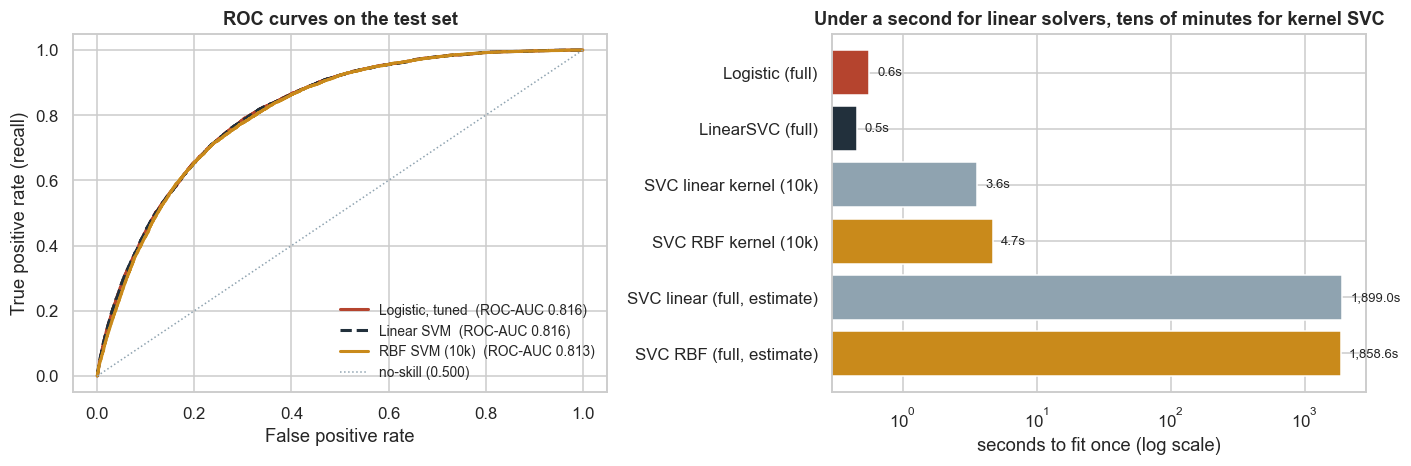

Share of test rows given the same label at F2 thresholds : 98.3%


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

curves = [("Logistic, tuned", p_lr, PALETTE["pos"], "-"),
          ("Linear SVM", d_svm, PALETTE["ink"], "--"),
          ("RBF SVM (10k)", d_rbf, PALETTE["accent"], "-")]
for name, s, color, ls in curves:
    fpr, tpr, _ = roc_curve(y_test, s)
    axes[0].plot(fpr, tpr, ls, color=color, lw=2,
                 label=f"{name}  (ROC-AUC {roc_auc_score(y_test, s):.3f})")
axes[0].plot([0, 1], [0, 1], color=PALETTE["neg"], lw=1, ls=":", label="no-skill (0.500)")
axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate (recall)")
axes[0].set_title("ROC curves on the test set")
axes[0].legend(frameon=False, fontsize=9, loc="lower right")

fit_times = pd.Series({
    "Logistic (full)":        lr_fit_time,
    "LinearSVC (full)":       svm_fit_time,
    "SVC linear kernel (10k)":  lin_sub_fit_time,
    "SVC RBF kernel (10k)":     rbf_fit_time,
    "SVC linear (full, estimate)": extrap["linear"],
    "SVC RBF (full, estimate)":  extrap["rbf"],
})
colors = [PALETTE["pos"], PALETTE["ink"], PALETTE["neg"],
          PALETTE["accent"], PALETTE["neg"], PALETTE["accent"]]
axes[1].barh(fit_times.index[::-1], fit_times.values[::-1], color=colors[::-1])
axes[1].set_xscale("log")
axes[1].set_xlabel("seconds to fit once (log scale)")
axes[1].set_title("Under a second for linear solvers, tens of minutes for kernel SVC")
for i, v in enumerate(fit_times.values[::-1]):
    axes[1].text(v * 1.15, i, f"{v:,.1f}s", va="center", fontsize=8.6)

plt.tight_layout(); plt.show()

same = ((p_lr >= lr_thr) == (d_svm >= svm_thr)).mean()
print(f"Share of test rows given the same label at F2 thresholds : {100*same:.1f}%")

Confusion matrices for the three main models at their F2 thresholds (Sydney's
side-by-side layout).

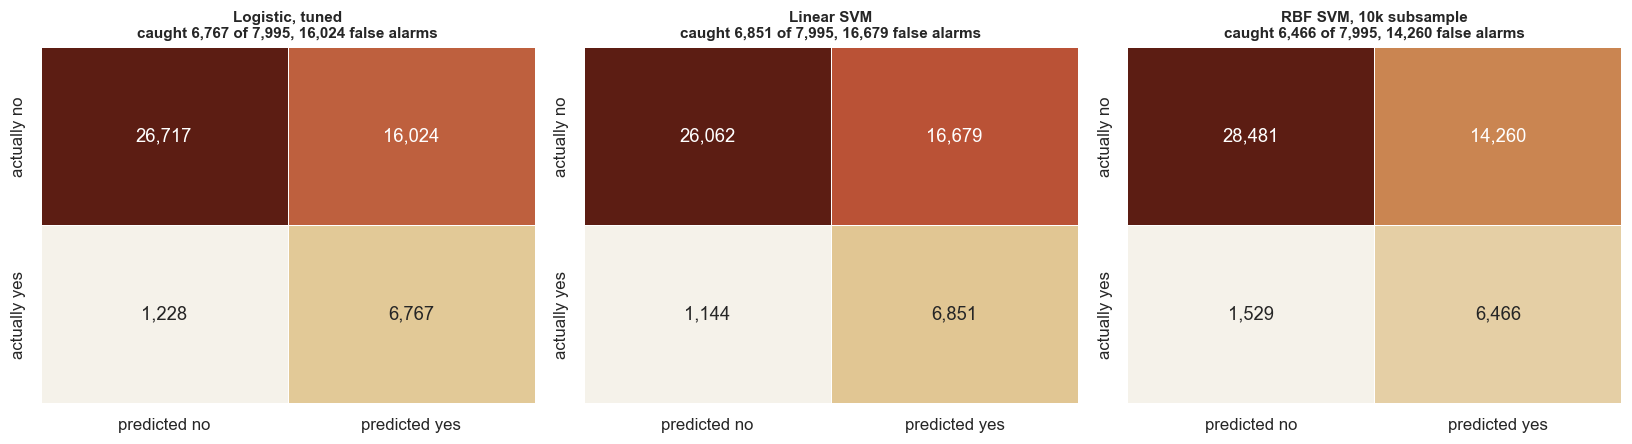

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, name in zip(axes, ["Logistic, tuned (F2 threshold)", "Linear SVM (F2 threshold)",
                           "RBF SVM, 10k subsample (F2 threshold)"]):
    cm = confusion_matrix(y_test, preds[name])
    sns.heatmap(cm, annot=True, fmt=",d", cmap=SEQ, cbar=False, ax=ax,
                linewidths=.6, linecolor="white", annot_kws={"fontsize": 12},
                xticklabels=["predicted no", "predicted yes"],
                yticklabels=["actually no", "actually yes"])
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f"{name.split(' (')[0]}\ncaught {tp:,} of {tp+fn:,}, {fp:,} false alarms",
                 fontsize=10)
plt.tight_layout(); plt.show()

### Does one model offer superior prediction performance?

No. Logistic regression ranks first on F2 (0.618) and the linear SVM second
(0.617), but the gap is in the third decimal. They give 98.3% of the test
respondents the same label, and their ROC curves are right on top of each other.
This makes sense, because both models draw a straight boundary using a weighted
sum of the same features, and here they end up with nearly the same weights
(Section 6.1).

The RBF kernel isn't better either (ROC-AUC 0.813 vs 0.816, F2 0.613), even
though it can draw a curved boundary. It flags fewer people, so it catches fewer
diabetics (6,466 vs 6,767 for logistic regression) with fewer false alarms.

In practice, the best model catches 6,767 of the 7,995 diagnosed diabetics in the
test set and raises 16,024 false alarms, about 2.4 for every case it finds. The
accuracy of these models (65-69%) is lower than predicting "no diabetes" for
everyone (84%), which is expected: we chose to accept many false alarms to miss
fewer cases.

### Does one offer superior training time or efficiency?

On the full data, logistic regression and `LinearSVC` both train in under a
second, so neither one is really faster. The big difference is the kernel
solver. `SVC` takes several seconds for 10,000 rows and would take about half an
hour for the full training set, and its prediction time grows with the number of
support vectors. The linear methods are thousands of times faster (right panel,
log scale).

### Advantages of each model for this task

| | Logistic regression | Linear SVM | RBF SVM |
|---|---|---|---|
| Accuracy (ROC-AUC / F2) | 0.816 / 0.618 | 0.816 / 0.617 | 0.813 / 0.613 (10k rows) |
| Output | A probability, which can be used directly as a risk score | A decision value with no probability scale | Same as linear SVM |
| Interpretability | Weights can be turned into odds ratios (Section 6) | Weights rank the features the same way, but can't be read as odds | No weight per feature |
| Training on 200k rows | < 1 s | < 1 s (`LinearSVC`) | About half an hour per fit (estimated) |
| Outliers | Every point affects the fit | Only points near the margin matter, so far-away points are ignored | Same as linear SVM |
| Non-linear patterns | Only if we add features by hand | Only if we add features by hand | Learned automatically |

For a screening tool on this data, we think logistic regression is the better
choice. It ties the SVM on accuracy and speed, and it gives a probability that is
easy to explain to a doctor ("your odds are about 1.7 times higher for each step
worse in general health"). The SVM's main advantage, ignoring points far from the
boundary, doesn't help here because most points are close to the boundary
(Section 7).

# 6. Interpreting the Logistic Regression Weights

The table below has four columns:

* weight: the coefficient from our tuned logistic regression. All features were
  standardized before fitting, so the weights are on the same scale and can be
  compared. A bigger weight (ignoring the sign) means the feature matters more to
  the model. A positive weight raises the predicted risk and a negative weight
  lowers it.
* odds ratio per unit: how much the odds of a diabetes diagnosis get multiplied
  by for one step of the feature in its own units (one BMI point, one age band,
  or yes vs no), *keeping the other 17 features the same*. Above 1 means higher
  odds and below 1 means lower odds.
* 95% CI and p-value: to get confidence intervals, we refit the same 18 features
  with `statsmodels`, which reports them (Wolfgang's approach). This refit has no
  class weights and no regularization, so its odds ratios are a little different
  from the tuned model's, but close (compare the two odds ratio columns).

In [16]:
scaler = lr_best.named_steps["scale"]
coef   = pd.Series(lr_best.named_steps["clf"].coef_[0], index=FEATURES)

# Wolfgang's statsmodels refit, for confidence intervals and p-values
logit = sm.Logit(y_train, sm.add_constant(X_train)).fit(disp=0)
ci = np.exp(logit.conf_int().loc[FEATURES])

weights = pd.DataFrame({
    "weight":               coef,
    "odds ratio per unit":  np.exp(coef / scaler.scale_),
    "OR (statsmodels)":     np.exp(logit.params[FEATURES]),
    "95% CI low":           ci[0],
    "95% CI high":          ci[1],
    "p-value":              logit.pvalues[FEATURES],
}).reindex(coef.abs().sort_values(ascending=False).index)

display(weights.round(3))
print(f"features with |weight| > 0.10 : {(coef.abs() > 0.10).sum()} of {len(coef)}")

,weight,odds ratio per unit,OR (statsmodels),95% CI low,95% CI high,p-value
GenHlth,0.602,1.758,1.683,1.654,1.711,0.000
BMI,0.508,1.080,1.064,1.062,1.067,0.000
Age,0.488,1.173,1.139,1.133,1.146,0.000
HighBP,0.343,2.000,2.061,2.000,2.125,0.000
HighChol,0.300,1.834,1.830,1.779,1.883,0.000
HvyAlcoholConsump,-0.139,0.546,0.513,0.475,0.554,0.000
Income,-0.129,0.940,0.948,0.941,0.955,0.000
Sex,0.121,1.275,1.264,1.229,1.300,0.000
HeartDiseaseorAttack,0.070,1.270,1.225,1.179,1.272,0.000
Education,-0.048,0.953,0.966,0.952,0.980,0.000


features with |weight| > 0.10 : 8 of 18


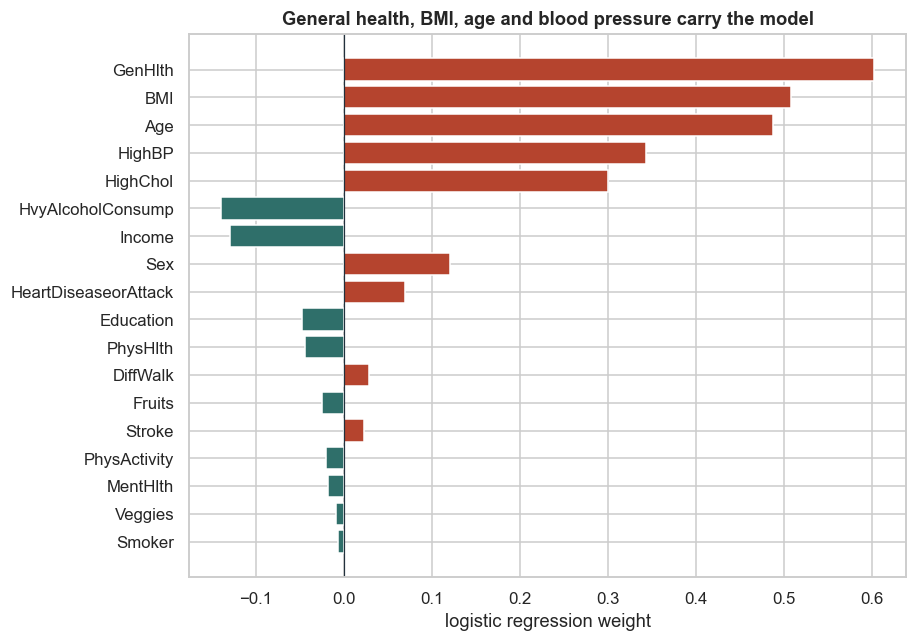

In [17]:
w_sorted = coef.reindex(coef.abs().sort_values().index)

fig, ax = plt.subplots(figsize=(8.5, 6))
ax.barh(w_sorted.index, w_sorted.values,
        color=[PALETTE["pos"] if v > 0 else PALETTE["prot"] for v in w_sorted.values])
ax.axvline(0, color=PALETTE["ink"], lw=0.8)
ax.set_xlabel("logistic regression weight")
ax.set_title("General health, BMI, age and blood pressure carry the model")
plt.tight_layout(); plt.show()

### Interpretation

Five features have much bigger weights than the rest: general health, BMI, age,
high blood pressure and high cholesterol, with weights between 0.30 and 0.60. The
next biggest is heavy alcohol use at 0.14. All five were in the top six of Lab 1's
Cramér's V table, and three of them (blood pressure, cholesterol and BMI) are the
"metabolic cluster" from Lab 1's Key Finding #2.

| Feature | Effect on the odds of diagnosis (statsmodels, 95% CI) |
|---|---|
| `HighBP` | 2.06x for someone told they have high blood pressure (2.00-2.13) |
| `HighChol` | 1.83x for high cholesterol (1.78-1.88) |
| `GenHlth` | 1.68x for each step worse on the 5-point self-rated health scale (1.65-1.71) |
| `Age` | 1.14x per five-year age band (1.13-1.15) |
| `BMI` | 1.064x per BMI point (1.062-1.067), so about 1.9x for 10 points |

The confidence intervals are narrow because there are so many rows. All but
three features have p-values below 0.01.

Why these features matter most: they are the most directly related to the
biology of diabetes. High blood pressure, high cholesterol and excess weight are
all part of metabolic syndrome, along with type 2 diabetes. They have shared
causes (like insulin resistance), and doctors often check blood sugar when they
find one of them, which also makes a *diagnosis* more likely. Age is the biggest
risk factor for type 2 diabetes, and older people have also had more years to get
tested. General health has the largest weight, but Lab 1 pointed out that it is
partly a result of diabetes: people with diabetes rate their health lower
*because* they have it. So it helps the model predict, but it isn't a cause.

Some weights were surprising:

* Heavy alcohol use lowers the odds (odds ratio 0.51, CI 0.48-0.55). This is very
  unlikely to be a real benefit. People diagnosed with diabetes are told to cut
  back on alcohol, and people who are already sick tend to drink less. So the
  diagnosis probably causes less drinking, not the other way around (reverse
  causation). Lab 1 found the same pattern for underweight BMI.
* Physical health days has a small negative weight (0.993 per day), even though
  diagnosed diabetics report more than twice as many bad physical-health days
  (7.96 vs 3.50 in the sample, Section 7). `GenHlth` and `DiffWalk` already carry
  most of that information (see the correlation check below), so what's left for
  `PhysHlth` is a small adjustment, and its sign doesn't mean much. A weight shows
  the effect of a feature *given the other features*, not its overall
  relationship with diabetes.
* Heart disease has a small weight (0.07, odds ratio 1.23) even though Lab 1
  found a strong association. Heart disease has the same causes as high blood
  pressure, high cholesterol and age, so those features take most of its weight.
  It is also a complication of diabetes, so the arrow can point both ways.
* Income is still negative (0.95x per income band) after accounting for health.
  People with lower income are more likely to be diagnosed even when they have
  the same BMI, blood pressure and self-rated health. This matches the income
  pattern in Lab 1. Since lower-income people have less access to testing, the
  real difference might be even bigger.
* Being male raises the odds by 1.26x (1.23-1.30), which fits with men developing
  type 2 diabetes at a lower BMI than women. Sex was 19th of 20 in Lab 1's
  Cramér's V table but is 8th here. On its own it doesn't separate the classes
  much, but for people with the same BMI and age the difference shows up.
  `DiffWalk` is the opposite: 4th in Cramér's V but 12th here, because difficulty
  walking mostly reflects poor health and high BMI, which are already in the model.
* Smoking, eating vegetables and mental health days don't matter. Their weights
  are the smallest in the model, their p-values are above 0.05, and their
  confidence intervals include 1.

### How big is the age effect?

Age is coded in 13 five-year bands, so its odds ratio is per band. Wolfgang's
age table compares each band with the youngest (18-24). Because age is one
numeric column here, the odds ratio for band *k* is the per-band odds ratio
raised to the power *k* - 1.

In [18]:
# Wolfgang's age table, using our single linear age term
AGE_GROUPS = ["18-24", "25-29", "30-34", "35-39", "40-44", "45-49", "50-54",
              "55-59", "60-64", "65-69", "70-74", "75-79", "80+"]
steps = np.arange(13)
age_or, age_lo, age_hi = (np.exp(logit.params["Age"] * steps),
                          ci.loc["Age", 0] ** steps, ci.loc["Age", 1] ** steps)
age_table = pd.DataFrame({"odds ratio vs 18-24": age_or, "95% CI low": age_lo,
                          "95% CI high": age_hi}, index=pd.Index(AGE_GROUPS, name="age group"))
display(age_table.iloc[[0, 2, 4, 6, 8, 10, 12]].round(2))

,odds ratio vs 18-24,95% CI low,95% CI high
age group,,,
18-24,1.000,1.000,1.000
30-34,1.300,1.280,1.310
40-44,1.690,1.650,1.720
50-54,2.190,2.110,2.260
60-64,2.840,2.710,2.970
70-74,3.690,3.480,3.900
80+,4.790,4.470,5.120


Under our straight-line age term, the odds of diagnosis rise steadily: about
1.7 times at 40-44, 2.8 times at 60-64 and 4.8 times at 80+, compared with 18-24.

This is where assumption 5 (ordinal features as numbers) matters most. Wolfgang
fit age with an extra squared term, which lets the curve bend. In his model the
odds rise much faster through middle age (about 4 times at 40-44 and 8.6 times at
60-64), then flatten after 65 and peak at 75-79 before a slight dip at 80+. That
matches the bend Lab 1 found in the oldest age bands. A single straight line
can't follow that shape, so our table understates the jump from young adulthood
to middle age. It doesn't change the ranking of features or the model's accuracy
much, since age is still one of the top three features either way.

### Checking the overlapping features

Several features measure similar things, which can move weight between them.
This correlation table (Sydney's check) shows the overlap among the health and
income features.

In [19]:
X_train[["GenHlth", "PhysHlth", "DiffWalk", "MentHlth", "Income", "Education", "Age"]].corr().round(2)

,GenHlth,PhysHlth,DiffWalk,MentHlth,Income,Education,Age
GenHlth,1.000,0.520,0.460,0.300,-0.370,-0.280,0.150
PhysHlth,0.520,1.000,0.480,0.350,-0.270,-0.150,0.100
DiffWalk,0.460,0.480,1.000,0.230,-0.320,-0.190,0.200
MentHlth,0.300,0.350,0.230,1.000,-0.210,-0.100,-0.090
Income,-0.370,-0.270,-0.320,-0.210,1.000,0.450,-0.130
Education,-0.280,-0.150,-0.190,-0.100,0.450,1.000,-0.100
Age,0.150,0.100,0.200,-0.090,-0.130,-0.100,1.000


General health is correlated with physical health days (0.52) and difficulty
walking (0.46), and income is correlated with education (0.45). This explains two
of the surprising weights above. Once `GenHlth` is in the model, `PhysHlth` and
`DiffWalk` have little new information to add, so their weights are small.
Education's weight (0.97x per level) is weaker than income's for the same
reason: the two overlap, and income takes most of the shared effect.

## 6.1 Do the SVM Weights Agree?

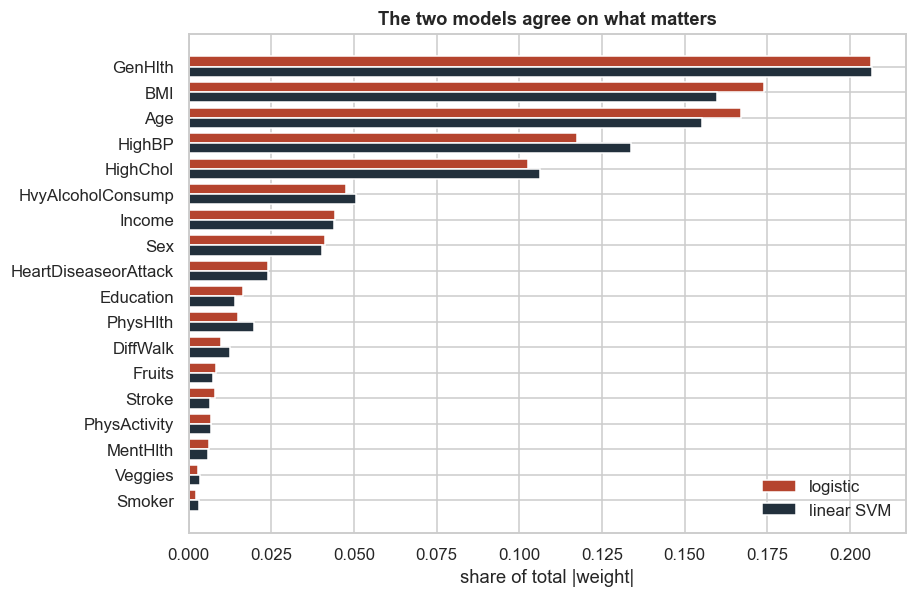

same sign on every feature : True
top five, logistic : ['GenHlth', 'BMI', 'Age', 'HighBP', 'HighChol']
top five, SVM      : ['GenHlth', 'BMI', 'Age', 'HighBP', 'HighChol']


In [20]:
svm_w = pd.Series(svm_best.named_steps["clf"].coef_[0], index=FEATURES)

# The two models use different losses, so the weights live on different scales;
# comparing each as a share of its own total magnitude puts them side by side
share = pd.DataFrame({"logistic": coef.abs() / coef.abs().sum(),
                      "linear SVM": svm_w.abs() / svm_w.abs().sum()})
share = share.sort_values("logistic")

fig, ax = plt.subplots(figsize=(8.5, 5.6))
ypos = np.arange(len(share))
ax.barh(ypos + 0.2, share["logistic"], 0.4, color=PALETTE["pos"], label="logistic")
ax.barh(ypos - 0.2, share["linear SVM"], 0.4, color=PALETTE["ink"], label="linear SVM")
ax.set_yticks(ypos); ax.set_yticklabels(share.index)
ax.set_xlabel("share of total |weight|")
ax.set_title("The two models agree on what matters")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

print(f"same sign on every feature : {bool((np.sign(coef) == np.sign(svm_w)).all())}")
print(f"top five, logistic : {coef.abs().nlargest(5).index.tolist()}")
print(f"top five, SVM      : {svm_w.abs().nlargest(5).index.tolist()}")

### Interpretation

The linear SVM's weights have the same sign as the logistic regression weights
for all 18 features, and both models have the same top five features. So the
feature importance results come from the data, not from the choice of logistic
regression. Sydney and Wolfgang each made the same comparison and found the same
agreement (rank correlation 0.97 and weight correlation 0.99).

# 7. Looking at the Support Vectors

Support vectors are the training points that define the SVM's boundary. They
are the points on the margin, inside the margin, or on the wrong side of the
boundary. All other points could be removed and the model would stay the same.

`LinearSVC` doesn't save its support vectors, so in this section we use the
linear-kernel `SVC` trained on the 10,000-row sample from Section 4.3. Its test
performance is close to the full-data linear SVM, so its support vectors should
be representative.

In [21]:
svc = lin_sub.named_steps["clf"]
sv_idx = X_sub.index[svc.support_]

sv_counts = pd.DataFrame({
    "rows in subsample": y_sub.value_counts().sort_index(),
    "support vectors":   y_sub.loc[sv_idx].value_counts().sort_index(),
}).rename(index={0: "no diabetes", 1: "diabetes"})
sv_counts["share that are SVs %"] = 100 * sv_counts["support vectors"] / sv_counts["rows in subsample"]
display(sv_counts.round(1))

print(f"support vectors : {len(sv_idx):,} of {len(X_sub):,} ({100*len(sv_idx)/len(X_sub):.0f}%)")

,rows in subsample,support vectors,share that are SVs %
Diabetes_binary,,,
no diabetes,8424,5086,60.400
diabetes,1576,958,60.800


support vectors : 6,044 of 10,000 (60%)


In [22]:
key = ["GenHlth", "BMI", "HighBP", "Age", "HighChol", "HeartDiseaseorAttack",
       "PhysHlth", "Income", "DiffWalk", "HvyAlcoholConsump"]

# Average of each feature for all rows, support vectors and the rest, by class
is_sv = X_sub.index.isin(sv_idx)
profile = {}
for label, cls in [("no diabetes", 0), ("diabetes", 1)]:
    in_cls = (y_sub == cls).values
    profile[(label, "all")]      = X_sub.loc[in_cls, key].mean()
    profile[(label, "SVs")]      = X_sub.loc[in_cls & is_sv, key].mean()
    profile[(label, "non-SVs")]  = X_sub.loc[in_cls & ~is_sv, key].mean()
profile = pd.DataFrame(profile)
display(profile.round(2))

no diabetes                diabetes               
                             all    SVs non-SVs      all    SVs non-SVs
GenHlth                    2.380  2.810   1.710    3.270  2.820   3.980
BMI                       27.770 29.330  25.390   31.360 29.340  34.490
HighBP                     0.370  0.590   0.030    0.740  0.590   0.960
Age                        7.730  8.940   5.900    9.270  8.950   9.780
HighChol                   0.370  0.540   0.130    0.660  0.540   0.840
HeartDiseaseorAttack       0.080  0.130   0.010    0.210  0.130   0.340
PhysHlth                   3.500  4.970   1.270    7.960  5.010  12.530
Income                     6.180  5.740   6.840    5.160  5.730   4.270
DiffWalk                   0.130  0.210   0.010    0.370  0.210   0.620
HvyAlcoholConsump          0.060  0.040   0.090    0.020  0.040   0.000

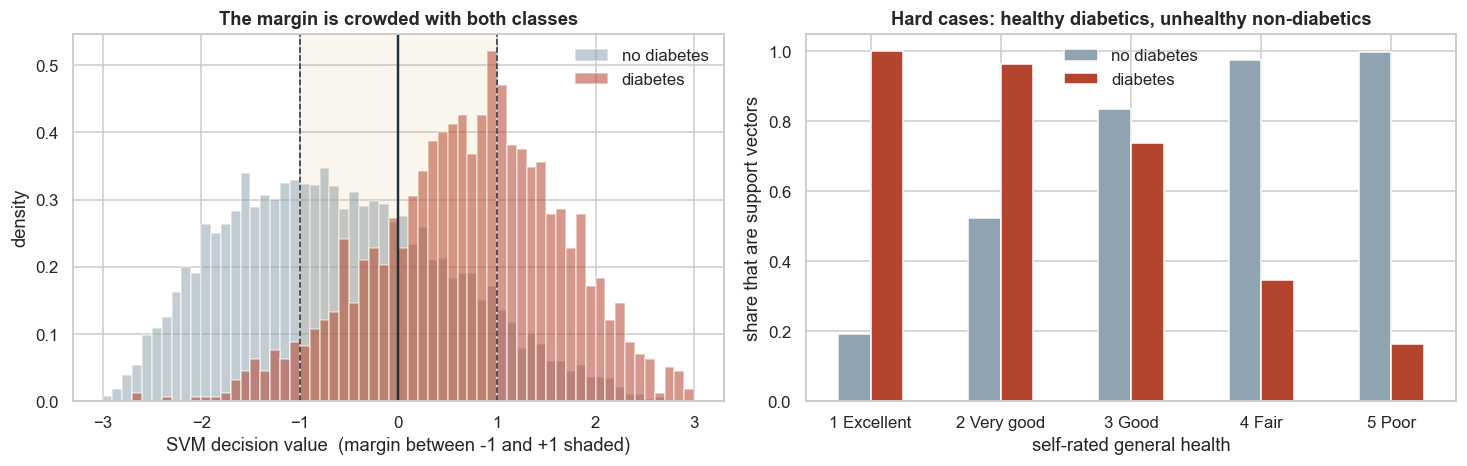

diabetes,no diabetes %,diabetes %
1 Excellent,19.000,100.000
2 Very good,52.000,96.000
3 Good,84.000,74.000
4 Fair,98.000,35.000
5 Poor,100.000,16.000


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4))

# Left: where the training rows fall relative to the margin
scores_sub = lin_sub.decision_function(X_sub)
bins = np.linspace(-3, 3, 61)
for cls, color, name in [(0, PALETTE["neg"], "no diabetes"), (1, PALETTE["pos"], "diabetes")]:
    axes[0].hist(scores_sub[(y_sub == cls).values], bins=bins, color=color,
                 alpha=0.55, density=True, label=name)
for x in (-1, 0, 1):
    axes[0].axvline(x, color=PALETTE["ink"], lw=1 if x else 1.6, ls="--" if x else "-")
axes[0].axvspan(-1, 1, color=PALETTE["accent"], alpha=0.08)
axes[0].set_xlabel("SVM decision value  (margin between -1 and +1 shaded)")
axes[0].set_ylabel("density")
axes[0].set_title("The margin is crowded with both classes")
axes[0].legend(frameon=False)

# Right: share of rows that are support vectors, by self-rated general health
# (Sydney's chart)
sv_share = (pd.DataFrame({"GenHlth": X_sub["GenHlth"].values, "SV": is_sv,
                          "diabetes": y_sub.values})
            .groupby(["GenHlth", "diabetes"])["SV"].mean().unstack())
sv_share.index = ["1 Excellent", "2 Very good", "3 Good", "4 Fair", "5 Poor"]
sv_share.plot(kind="bar", ax=axes[1], color=[PALETTE["neg"], PALETTE["pos"]], rot=0)
axes[1].set_xlabel("self-rated general health")
axes[1].set_ylabel("share that are support vectors")
axes[1].set_title("Hard cases: healthy diabetics, unhealthy non-diabetics")
axes[1].legend(["no diabetes", "diabetes"], frameon=False)
plt.tight_layout(); plt.show()

display((100 * sv_share).round(0).rename(columns={0: "no diabetes %", 1: "diabetes %"}))

### What the support vectors tell us

60% of the sample are support vectors, and the share is about the same in each
class. If the classes were clearly separated there would only be a few support
vectors. Here the SVM needs most of the training rows to place the boundary,
which shows that the two classes overlap a lot. Lab 1 found the same thing with
PCA: the diabetic group was shifted a little but mostly covered the same area as
the non-diabetic group. It also explains why no model got a ROC-AUC above 0.82.

Support vectors from the two classes look almost the same. In the profile table,
non-diabetic support vectors have an average general health of 2.81, BMI 29.3,
59% with high blood pressure and age band 8.9 (about 60). Diabetic support vectors
average 2.82, 29.3, 59% and 8.95. On paper they are the same kind of person:
middle-aged, overweight, in fair-to-good health, and about 60% with high blood
pressure. The non-diabetic support vectors are sicker than the average
non-diabetic (general health 2.81 vs 2.38, BMI 29.3 vs 27.8), and the diabetic
support vectors are healthier than the average diabetic (2.82 vs 3.27, BMI 29.3
vs 31.4). So from each class, the support vectors are the people who look most
like the other class.

The chart on the right shows this by general health. Every diabetic who rates
their health as excellent is a support vector, and so is every non-diabetic who
rates it as poor (98% for fair). The hard cases are healthy-looking diabetics
and unhealthy-looking non-diabetics.

The rows that are not support vectors are the easy cases. The non-diabetics the
model doesn't need are younger (age band 5.9, late 40s), leaner (BMI 25.4),
almost never have high blood pressure (3%) and rate their health as very good
(1.71). The diabetics it doesn't need are the opposite: BMI 34.5, 96% with high
blood pressure, fair-to-poor health (3.98) and 12.5 bad physical-health days a
month. The model separates these extremes easily, and most of its mistakes come
from the big group in the middle.

What this tells us about the data:

1. Some non-diabetic support vectors are probably undiagnosed diabetics. They
   have the diabetic risk profile but no diagnosis. Lab 1 suggested that some of
   the "negatives" in this data are undiagnosed cases, and this is where we would
   expect to find them. If so, some of our "false alarms" are real cases, and the
   precision we measured is lower than the true precision.
2. Some diabetic support vectors are probably well-managed diabetics (Sydney's
   point). People who lost weight, control their blood pressure and feel healthy
   after being diagnosed no longer look like the typical diabetic profile.
3. Better models won't fix this, but better features would. Separating these
   groups would need clinical measurements such as blood glucose or HbA1c, which
   a phone survey doesn't collect.

# 8. Conclusions

1. Logistic regression and the linear SVM performed the same. On the 50,736-row
   test set both got a ROC-AUC of 0.82 (guessing would be 0.50) and an F2 of
   0.62, and they gave 98.3% of people the same label. At their F2 thresholds
   they find about 85% of diagnosed diabetics at 29-30% precision, which means
   about 2.4 false alarms for each case found.

2. Tuning the parameters changed almost nothing, and the threshold mattered more.
   With 203k rows and 18 features neither model overfits, so `C`, the penalty
   and the class weight didn't change the ranking across the whole range we
   tried. What changed the results was the decision threshold (or equally, the
   class weight), which controls the tradeoff between recall and precision. That
   is a decision about how costly each kind of error is, not about how good the
   model is.

3. The linear kernel is the right choice for this data. Kernel `SVC` time grows
   with the square of the rows, so at 203k rows each fit would take about half an
   hour. An RBF kernel trained on 10,000 rows did not beat the linear models
   (ROC-AUC 0.813 vs 0.816), and Wolfgang's wider screen of 36 kernel settings
   found at most +0.002.

4. Five features matter most: general health, BMI, age, high blood pressure and
   high cholesterol. The logistic regression weights and the linear SVM weights
   agree on this, and it matches our EDA from Lab 1. Heavy alcohol use and
   physical-health days look protective, but this comes from reverse causation
   and overlapping features, not a real benefit.

5. The support vectors show how much the classes overlap. 60% of the training
   rows are support vectors, and the support vectors from both classes have
   almost the same average profile. The boundary is set by a large middle group
   of middle-aged, overweight people in fair health who could be in either class.
   Better tuning won't fix this. We would need better features, like a blood
   glucose or HbA1c test, instead of survey answers.

Next steps: F2 is a convenient way to say that recall matters more than
precision, but it is only an estimate of that tradeoff. With real numbers for the
cost of a screening test and the cost of a missed diagnosis, the threshold could
be set to match those costs directly (Wolfgang's suggestion). Adding a squared
age term would also capture the age curve better (Section 6).

Limitations: the target is a self-reported diagnosis, so the models learn who
gets diagnosed, not who has diabetes. We treated ordinal features as linear. The
RBF comparison only used 5% of the training data. Also, the sample is much older
than the US adult population (Lab 1, Section 5), so these results describe BRFSS
respondents and not the general public.

# 9. Sources

scikit-learn developers. *scikit-learn User Guide and API Reference*, version 1.9. The following pages were used:

1. Setup (train/test split, scaling, pipelines)
   - `train_test_split`: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
   - `StandardScaler`: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html
   - Pipelines: https://scikit-learn.org/stable/modules/compose.html#pipeline

2. Logistic regression, class weights, regularization and threshold
   - `LogisticRegression`: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
   - `DummyClassifier`: https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html
   - Cross-validation: https://scikit-learn.org/stable/modules/cross_validation.html
   - Grid search: https://scikit-learn.org/stable/modules/grid_search.html
   - Tuning the decision threshold: https://scikit-learn.org/stable/modules/classification_threshold.html
   - `fbeta_score`: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.fbeta_score.html

3. Support vector machines
   - SVM user guide: https://scikit-learn.org/stable/modules/svm.html
   - RBF SVM parameters: https://scikit-learn.org/stable/auto_examples/svm/plot_rbf_parameters.html
   - `LinearSVC`: https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html

4. Comparing the models
   - Logistic regression: https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
   - James, G., Witten, D., Hastie, T. and Tibshirani, R. *An Introduction to Statistical Learning*, Section 9.5, "Relationship to Logistic Regression".

5. Interpreting the weights
   - Common pitfalls in the interpretation of coefficients of linear models: https://scikit-learn.org/stable/auto_examples/inspection/plot_linear_model_coefficient_interpretation.html
   - statsmodels `Logit`: https://www.statsmodels.org/stable/generated/statsmodels.discrete.discrete_model.Logit.html

6. Support vectors
   - SVM mathematical formulation: https://scikit-learn.org/stable/modules/svm.html#mathematical-formulation
   - SVM maximum margin separating hyperplane: https://scikit-learn.org/stable/auto_examples/svm/plot_separating_hyperplane.html